<a href="https://colab.research.google.com/github/EaganKyoji/AI-project/blob/main/Analisis_Sentimen_Gojek.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Perkanalan Dataset
---


Dataset diambil dari Kaggle berjumlah ... baris. Kemudian dilakukan pemilahan label secara subjektif dengan ketentuan:
1-2 Negatif
3 Netral
4-5 Positif

In [ ]:
import pandas as pd

df = pd.read_csv('/content/sample_data/GojekAppReviewV4.0.0-V4.9.3_Cleaned.csv')

df.head()

,userName,content,score,at,appVersion
0,Yuga Edit,akun gopay saya di blok,1,2022-01-21 10:52:12,4.9.3
1,ff burik,Lambat sekali sekarang ini bosssku apk gojek g...,3,2021-11-30 15:40:38,4.9.3
2,Anisa Suci Rahmayuliani,Kenapa sih dari kemarin sy buka aplikasi gojek...,4,2021-11-29 22:58:12,4.9.3
3,naoki yakuza,Baru download gojek dan hape baru trus ditop u...,1,2022-09-03 15:21:17,4.9.3
4,Trio Sugianto,Mantap,5,2022-01-15 10:05:27,4.9.3


In [ ]:
def sentiment_label(score):
    if score <= 2:
        return 'negative'
    elif score == 3:
        return 'neutral'
    else:
        return 'positive'

df['sentiment'] = df['score'].apply(sentiment_label)

In [ ]:
df[['score', 'sentiment']].head()

,score,sentiment
0,1,negative
1,3,neutral
2,4,positive
3,1,negative
4,5,positive


#Pemahaman Dataset
---


Pada bagian ini kita perlu memahami dataset yang kita gunakan. Mulai dari cek bentuk data, distribusi rating, kemudian kita lakukan visualisasi pada distributi label

In [ ]:
print("\nInformasi dataset:")
df.info()
print("Bentuk dataset:")
df.shape



Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225002 entries, 0 to 225001
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   userName    225002 non-null  object
 1   content     225000 non-null  object
 2   score       225002 non-null  int64 
 3   at          225002 non-null  object
 4   appVersion  225002 non-null  object
 5   sentiment   225002 non-null  object
dtypes: int64(1), object(5)
memory usage: 10.3+ MB
Bentuk dataset:


(225002, 6)

In [ ]:
print("\nNull value pada dataset:")
df.isnull().sum()


Null value pada dataset:


,0
userName,0
content,2
score,0
at,0
appVersion,0
sentiment,0


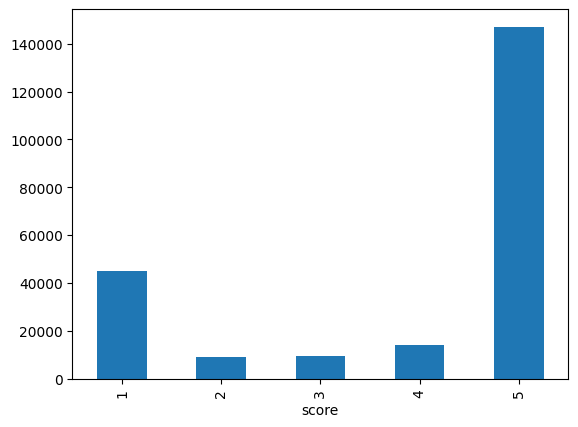

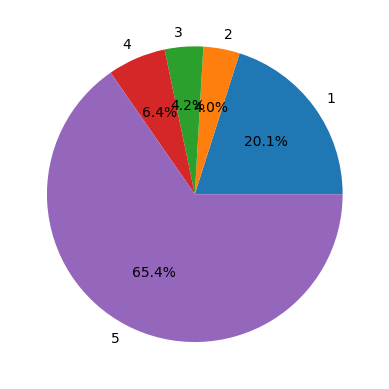

In [ ]:
import matplotlib.pyplot as plt

df['score'].value_counts().sort_index().plot(kind='bar')
plt.show()
print("\n")
df['score'].value_counts().sort_index().plot(
    kind='pie',
    autopct='%1.1f%%',
    ylabel='')
plt.show()


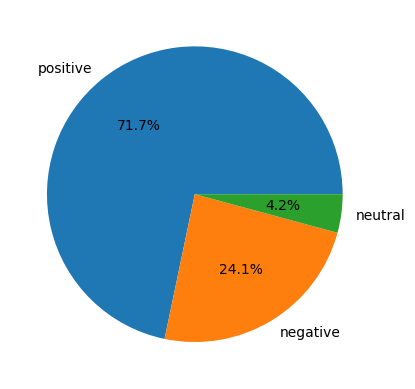

In [ ]:
dt = df['sentiment'].value_counts(normalize=True) * 100
dt.plot(kind='pie', autopct='%1.1f%%', ylabel='')
plt.show()

In [ ]:
print("POSITIVE")
print(df[df['sentiment']=='positive']['content'].iloc[0])

print("\nNEGATIVE")
print(df[df['sentiment']=='negative']['content'].iloc[0])

print("\nNEUTRAL")
print(df[df['sentiment']=='neutral']['content'].iloc[0])

POSITIVE
Kenapa sih dari kemarin sy buka aplikasi gojek malah keluar sendiri terus Saya kasih bintang 2 dulu kalo sudah normal sy kasih bintang 7

NEGATIVE
akun gopay saya di blok

NEUTRAL
Lambat sekali sekarang ini bosssku apk gojek gk kaya dulu


In [ ]:
df['text_length'] = df['content'].astype(str).apply(len)

df['text_length'].describe()

,text_length
count,225002.000000
mean,51.411236
std,74.673784
min,1.000000
25%,7.000000
50%,22.000000
75%,62.000000
max,650.000000


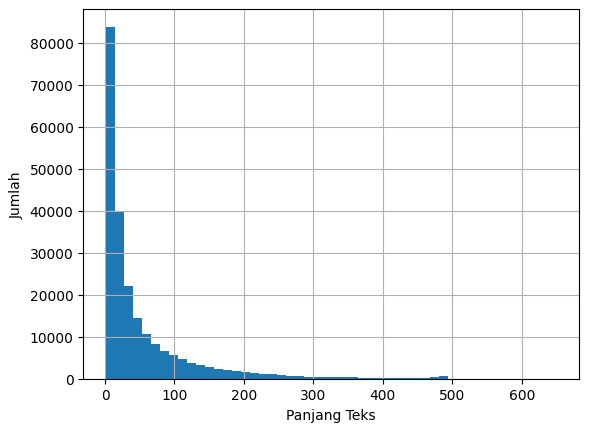

In [ ]:
df['text_length'].hist(bins=50)

plt.xlabel("Panjang Teks")
plt.ylabel("Jumlah")
plt.show()

#Cleaning Data
---
Pada proses ini, data akan dibersihkan dan dilakukan konsistensi seperti penyeragaman lowercase, penghapusan URL, penghapusan emoji, penghapusan simbol, punctuation, angka, dll

In [ ]:
import re

def clean_text(text):
    text = text.lower()

    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'www\S+', '', text)

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    text = text.strip()

    return text

df['clean_text'] = df['content'].astype(str).apply(clean_text)

In [ ]:
pip install Sastrawi

In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

df['stemmed'] = df['clean_text'].apply(stemmer.stem)

#Train Test Split
---
Pembagian dataset untuk menjadi data training dan data testing sebagai bahan latihan dan bahan uji dari sebuah model

In [ ]:
from sklearn.model_selection import train_test_split

x_train_text, x_test_text, y_train, y_test = train_test_split(
    df['clean_text'],
    df['sentiment'],
    test_size = 0.2,
    random_state = 42,
    stratify = df['sentiment']
)

#TF IDF
---
Metode statistik pada bidang NLP untuk menilai seberapa penting suat kata pada dokumen dengan relasinya pada dokumen yang lebih besar
TF (Term Frequency)
>Menghitung banyaknya kata yang sering muncul pada suatu dokumen, kalau sering muncul berarti kata tersebut penting di dokumen itu

IDF(Inverse Document Frequency)
>Mengurangi banyak kata sering muncul pada banyak dokumen dan meningkatkan bobot untuk kata yang jarang muncul di dokumen. Apabila sebuah kata muncul lebih sedikit artinya itu mengacu pada kata teknis dan lebih bermakna

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000,
                             ngram_range=(1,2))

x_train = tfidf.fit_transform(x_train_text)
x_test = tfidf.transform(x_test_text)

#Model Logistic Regression
---
Pada tahap ini, model logistic regression akan dibuat dan diimplementasikan pada data train

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced')

model.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced')

#Evaluasi
---
Pada tahap ini, model akan dinilai hasil evaluasinya menggunakan classification report dengan library sklearn.metrics. Evaluasinya meliputi beberapa penilaina seperti:
Akurasi: seberapa tepat mengukur suatu model
Precision: dari semua yang diprediksi positif berapa yang benar-benar positif (mencegah false alarm)

In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(x_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.79      0.72      0.75     10834
     neutral       0.14      0.43      0.21      1892
    positive       0.97      0.88      0.92     32275

    accuracy                           0.82     45001
   macro avg       0.63      0.68      0.63     45001
weighted avg       0.89      0.82      0.85     45001

